# Импорт библиотек и задание параметров

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
from scipy.linalg import eig

# Параметры модели (таблица 1)
a = 0.2        # макс скорость роста фито Р
b = 0.2        # ослабление света (убыль Р)
c = 0.4        # самозатемнение фито Р  (убыль Р)
e = 0.03       # полунасыщение поглощения био N
lambd = 0.6    # макс скорость выедания фито (убыль P и рост Z)
mu = 0.035     # полунасыщение выедания фито
r = 0.15       # отмирание фито Р
s = 0.04       # оседание фито Р  (убыль P)
k = 0.05       # скорость обновления био N
N0 = 0.6       # концентрация био N под слоем
alpha = 0.25   # эффективность роста зоо Z
beta = 0.33    # доля экскреции зоо Z (рост N)
gamma = 0.5    # регенерация био N


# Для m=1 (линейное) параметр d (q) = 0.075 (по умолчанию)
# Для m=2 (квадратичное) параметр d = 1.0 (по умолчанию)

# Определение системы ОДУ

Функция system вычисляет правые части системы ОДУ для текущих концентраций N, P, Z.

Возвращает список производных [dN/dt, dP/dt, dZ/dt].

In [2]:
def system(t, y, d, m):
    """
    Правая часть системы ОДУ
    y = [N, P, Z] текущее значение
    d – коэффициент смертности зоо Z
    m – показатель замыкания
    """
    N, P, Z = y

    growth = (a / (b + c * P)) * (N / (e + N))      # рост фито
    grazing = lambd * P**2 / (mu**2 + P**2)         # выедание (Холлинг III)
    closure = d * Z**m                              # замыкание

    dN = -growth * P + r * P + beta * grazing * Z + gamma * closure + k * (N0 - N)
    dP = growth * P - r * P - grazing * Z - (s + k) * P
    dZ = alpha * grazing * Z - closure
    return [dN, dP, dZ]

# Поиск стационарных точек (равновесий)
Стационарная точка – это решение системы, все уравнения равны 0.
Это нужно, чтобы обнаружить переход от стабильного состояния к автоколебаниям и построить график зависимости от параметра.

Функция find_equilibrium численно находит стационарную точку системы при заданных d и m. Используется fsolve для решения системы, приравненной к 0. Проверяется успешность решения и неотрицательность переменных. Отрицательные или слишком малые значения Z отбрасываются.

In [3]:
def find_equilibrium(d, m, guess):
    """
    Находит стационарную точку (N*, P*, Z*) с положительными значениями.
    Возвращает массив [N, P, Z] или None, если решение не найдено.
    guess - начальное приближение для fsolve
    """
    try:
        sol = fsolve(lambda y: system(0, y, d, m), guess, full_output=True, xtol=1e-10)
        if sol[2] == 1:  # успешное решение
            y = sol[0]
            # Проверяем, что все переменные неотрицательны и не слишком маленькие
            if np.all(y >= 0) and y[2] > 1e-5:
                return y
    except:
        pass
    return None

# Проверка устойчивости равновесия (собственные числа Якоби)
Необходимо  определить, в каких интервалах параметра система будет колебаться.

Функция stability вычисляет устойчивость стационарной точки y=[N,P,Z] для заданных параметров d и m.

В найденной точке мы вычисляем матрицу Якоби (численно, через малые приращения) и находим её собственные числа. Если все вещественные части отрицательны – равновесие устойчиво. Если есть положительная – неустойчиво. Момент перехода через ноль – это бифуркация Хопфа.

In [4]:
def stability(y, d, m):
    """
    Вычисляет максимальную вещественную часть собственных чисел матрицы Якоби.
    Если max_real < 0 – равновесие устойчиво, иначе – неустойчиво.
    """
    # метод центральной разности
    eps = 1e-8
    J = np.zeros((3, 3))
    for i in range(3):
      # отклоняем i-ю компоненту на маленькое число
        y_plus = y.copy(); y_plus[i] += eps
        y_minus = y.copy(); y_minus[i] -= eps
      # вычисляем правые части
        f_plus = system(0, y_plus, d, m)
        f_minus = system(0, y_minus, d, m)

        J[:, i] = (np.array(f_plus) - np.array(f_minus)) / (2 * eps) # считаем приближение производной
    eigvals = eig(J)[0] # вычисляем собственные числа
    return np.max(eigvals.real)

# Нахождение предельного цикла
Если равновесие неустойчиво, система выходит на предельный цикл – устойчивые периодические колебания.
Интегрируем ОДУ на промежутке времени 200 дней из начального состояния (из статьи).
Находим минимальные и максимальные значения N,P,Z для каждого цикла.

In [5]:
def get_cycle_extremes(d, m, y0):
    """
    Интегрирует систему и возвращает минимальные и максимальные значения N, P, Z.
    y0 - начальные приближения [N0, P0, Z0]
    """
    t_span=(0, 200) # интервал времени интегрирования
    t_eval = np.linspace(t_span[0], t_span[1], 500)
    # численное интегрирование (автоматически подбирается нужный метод)
    sol = solve_ivp(lambda t, y: system(t, y, d, m), t_span, y0, t_eval=t_eval, method='LSODA')

    # Извлекаем значения
    N_vals = sol.y[0, :]
    P_vals = sol.y[1, :]
    Z_vals = sol.y[2, :]
    return {
        'N_min': np.min(N_vals), 'N_max': np.max(N_vals),
        'P_min': np.min(P_vals), 'P_max': np.max(P_vals),
        'Z_min': np.min(Z_vals), 'Z_max': np.max(Z_vals)
    }

Для каждого значения параметра d мы записываем:

Если равновесие устойчиво – значение переменной в равновесии.

Если неустойчиво – точки максимума и минимума цикла.

Запоминаем флаг изменения устойчивости, чтобы потом построить график.

In [6]:
def bifurcation_scan(m, d_range, guess_init):
    """
    d_range – массив значений d
    guess_init – начальное приближение для поиска равновесия
    Возвращает  d_vals, P_eq, stable_flags, P_max, P_min (и аналогично для N, Z)
    """
    d_vals = []
    P_eq = []; N_eq = []; Z_eq = []
    stable_flags = []
    P_max = []; P_min = []; N_max = []; N_min = []; Z_max = []; Z_min = []

    guess = guess_init
    for d in d_range:
        eq = find_equilibrium(d, m, guess) # для каждого d ищем равновесие
        if eq is not None:
            # Проверка положительности
            if np.any(eq < 0):
                continue

            # Сохраняем равновесие
            d_vals.append(d)
            N_eq.append(eq[0]); P_eq.append(eq[1]); Z_eq.append(eq[2])
            # Устойчивость
            max_real = stability(eq, d, m)
            stable = max_real < 0
            stable_flags.append(stable) # для разделения равновесия и циклов
            # Обновляем guess для продолжения
            guess = eq

            # Если неустойчиво
            if (not stable):
                # Начальное условие – слегка возмущённое равновесие
                y0 = eq + np.array([0, 0.001, 0])
                ext = get_cycle_extremes(d, m, y0) # ищем экстремумы
                if ext is not None:
                    P_max.append(ext['P_max']); P_min.append(ext['P_min'])
                    N_max.append(ext['N_max']); N_min.append(ext['N_min'])
                    Z_max.append(ext['Z_max']); Z_min.append(ext['Z_min'])
                else:
                  # если цикл не найден, заполняем NaN
                    P_max.append(np.nan); P_min.append(np.nan)
                    N_max.append(np.nan); N_min.append(np.nan)
                    Z_max.append(np.nan); Z_min.append(np.nan)
            else:
              # если равновесие устойчиво, заполняем NaN
                P_max.append(np.nan); P_min.append(np.nan)
                N_max.append(np.nan); N_min.append(np.nan)
                Z_max.append(np.nan); Z_min.append(np.nan)
        else:
            # Если равновесие не найдено, пропускаем точку
            pass
    return (np.array(d_vals), np.array(N_eq), np.array(P_eq), np.array(Z_eq),
            np.array(stable_flags),
            np.array(N_max), np.array(N_min),
            np.array(P_max), np.array(P_min),
            np.array(Z_max), np.array(Z_min))

Определяем начальное приближение, диапазоны параметров и вызываем функцию bifurcation_scan для двух случаев замыкания.

In [12]:
# Начальное приближение для равновесия при стандартных параметрах
guess_init = np.array([0.3, 0.35, 0.07])

# Диапазоны параметров
d_range_1 = np.linspace(0.015, 0.15, 50)   # для m=1 (q)
d_range_2 = np.linspace(0.0, 2.0, 50)     # для m=2 (d)

# Поиск для m=1
d1, N1, P1, Z1, stab1, Nmax1, Nmin1, Pmax1, Pmin1, Zmax1, Zmin1 = bifurcation_scan(1, d_range_1, guess_init)

# Поиск для m=2
d2, N2, P2, Z2, stab2, Nmax2, Nmin2, Pmax2, Pmin2, Zmax2, Zmin2 = bifurcation_scan(2, d_range_2, guess_init)

# Построение бифуркационной диаграммы
Мы строим три графика: для N, P и Z.

По второй оси - изменение значения параметра d(q) в его собственном диапозоне, взятом из статьи.
На графике сплошной линии принадлежат точки в стабильном состоянии, а пунктирной - перешедшие в предельные циклы. Точки в диапазоне, которому принадлежит пукнтирная линия, показывают максимумы и минимумы значения концентрации в цикле.

In [8]:
def plot_branch(ax, x, y, stab,
                y_max=None, y_min=None,
                xlabel='', ylabel='', title=''):
    """
    Рисует бифуркационную ветвь с автоматическим изменением стиля
    """
    x = np.asarray(x)
    y = np.asarray(y)
    stab = np.asarray(stab, dtype=bool)

    # Индексы, где меняется устойчивость
    indices = np.where(np.diff(stab.astype(int)) != 0)[0] + 1
    indices = np.concatenate(([0], indices, [len(x)]))

    stable_labeled = False
    unstable_labeled = False

    for i in range(len(indices) - 1):
        start, end = indices[i], indices[i+1]
        if start >= end:
            continue
        if stab[start]:
            label = 'стабильное состояние' if not stable_labeled else ''
            ax.plot(x[start:end], y[start:end], 'b-', linewidth=2, label=label)
            stable_labeled = True
        else:
            label = 'нестабильное' if not unstable_labeled else ''
            ax.plot(x[start:end], y[start:end], 'r--', linewidth=2, label=label)
            unstable_labeled = True

    # Экстремумы предельных циклов
    mask_cycle = ~np.isnan(y_max)
    if np.any(mask_cycle):
        ax.plot(x[mask_cycle], y_max[mask_cycle], 'ko', markersize=3, label='макс цикла')
        ax.plot(x[mask_cycle], y_min[mask_cycle], 'ko', markersize=3, label='мин цикла')

    # Точки бифуркаций Хопфа (смена устойчивости)
    diff = np.diff(stab.astype(int))
    hopf_idx = np.where(diff != 0)[0]
    if len(hopf_idx) > 0:
        hopf_x = x[hopf_idx]
        hopf_y = y[hopf_idx]
        ax.plot(hopf_x, hopf_y, 'ks', markersize=8, label='бифуркация Хопфа')

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True)

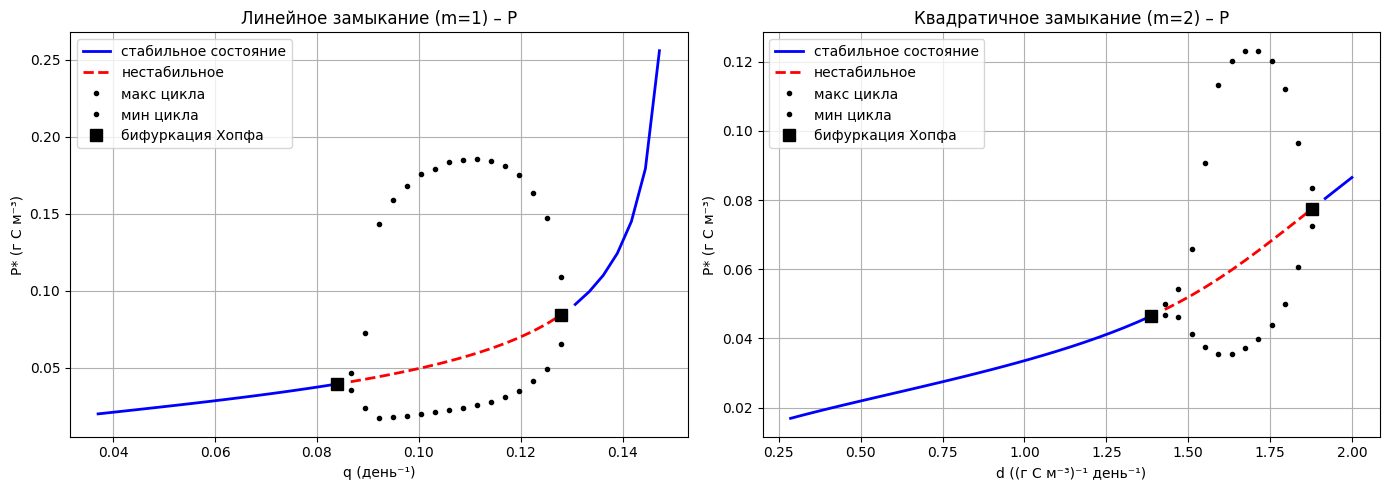

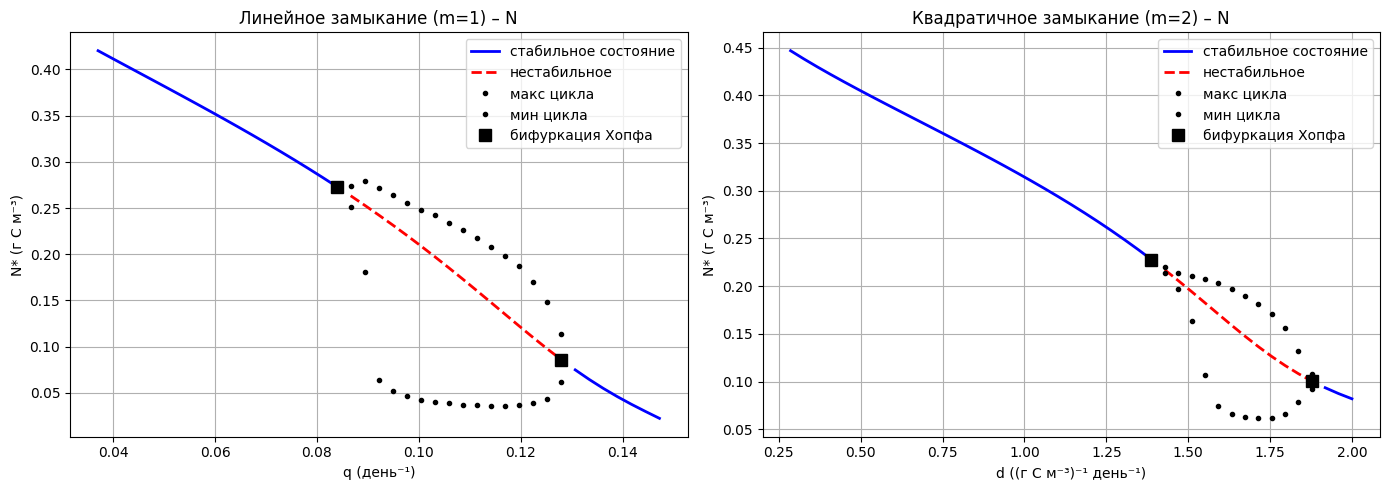

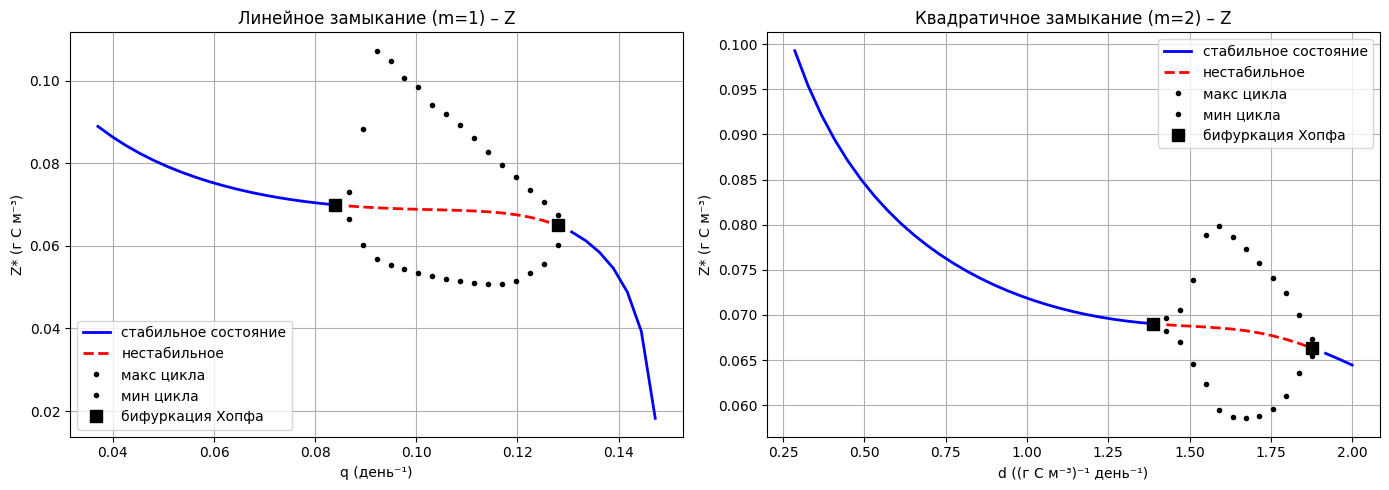

In [13]:
# Список переменных для построения
variables = [
    ('P', 'P* (г C м⁻³)', P1, P2, Pmax1, Pmin1, Pmax2, Pmin2),
    ('N', 'N* (г C м⁻³)', N1, N2, Nmax1, Nmin1, Nmax2, Nmin2),
    ('Z', 'Z* (г C м⁻³)', Z1, Z2, Zmax1, Zmin1, Zmax2, Zmin2)
]

for var_name, ylabel, y1, y2, ymax1, ymin1, ymax2, ymin2 in variables:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # m=1 (линейное)
    ax = axes[0]
    plot_branch(ax, d1, y1, stab1,
                y_max=ymax1, y_min=ymin1,
                xlabel='q (день⁻¹)', ylabel=ylabel,
                title=f'Линейное замыкание (m=1) – {var_name}')

    # m=2 (квадратичное)
    ax = axes[1]
    plot_branch(ax, d2, y2, stab2,
                y_max=ymax2, y_min=ymin2,
                xlabel='d ((г C м⁻³)⁻¹ день⁻¹)', ylabel=ylabel,
                title=f'Квадратичное замыкание (m=2) – {var_name}')

    plt.tight_layout()
    plt.show()

Из графика видно, что при m=1 значение q, в котором наступает первая бифуркация Хопфа, лежит в диапазоне 0.08 - 0.1; вторая бифуркация в 0.12 - 0.14.

Для m=2 соответсвующие значения d находятся в диапазонах 1.25-1.5 и 1.75-2.0.

Такой разброс в значениях объясняется разными единицами измерения коэффициентов из-за изменения размерности Z в члене замыкания.

Определим конкретные значения по флагам перехода состояний.

In [14]:
# Для m=1
idx_unstable1 = np.where(~stab1)[0]
q_low = d1[idx_unstable1[0]]
q_high = d1[idx_unstable1[-1]]
print(f'm=1: колебания при q от {q_low:.4f} до {q_high:.4f}')

# Для m=2
idx_unstable2 = np.where(~stab2)[0]
d_low = d2[idx_unstable2[0]]
d_high = d2[idx_unstable2[-1]]
print(f'm=2: колебания при d от {d_low:.4f} до {d_high:.4f}')


m=1: колебания при q от 0.0866 до 0.1280
m=2: колебания при d от 1.4286 до 1.8776


Для сравнения ширирны диапазона параметров, необходимо вычислить их относительные значения. За полный диапазон параметра возьмем значения, которые использовали в рассчетах и построении диаграмм.

In [15]:
# Полный диапазон параметров
total_range_1 = d_range_1[-1] - d_range_1[0]
total_range_2 = d_range_2[-1] - d_range_2[0]

# Для m=1
unstable_width_1 = q_high - q_low
rel_width_1 = unstable_width_1 / total_range_1
print(f'm=1: относительная ширина диапазона {rel_width_1*100:.1f}%')

# Для m=2
unstable_width_2 = d_high - d_low
rel_width_2 = unstable_width_2 / total_range_2
print(f'm=2: относительная ширина диапазона {rel_width_2*100:.1f}%')

m=1: относительная ширина диапазона 30.6%
m=2: относительная ширина диапазона 22.4%


Исходя из результатов, ширина диапазона параметра d, в котором вознакают коллебания, при линейном замыкании шире, чем при квадратичном.

# Построение временных рядов
Выбираем два значения параметра для каждого m: одно – до бируфикации (равновесие), другое – между двумя точками бируфикации.

Для m=1: 0.075 и 0.11, для m=2: 1.1 и 1.5.

 Интегрируем систему и строим графики N(t),P(t),Z(t) для каждого значения параметра. Это наглядно показывает переход от стационарного состояния к колебаниям и удобно для сравнения с рисунками из статьи.

In [16]:
# Функция для построения временных рядов
def plot_time_series(d, m, y0, t_span=(0, 300), title=''):
    t_eval = np.linspace(t_span[0], t_span[1], 3000)
    sol = solve_ivp(lambda t, y: system(t, y, d, m),
                    t_span, y0, t_eval=t_eval, method='LSODA')
    plt.figure(figsize=(10, 4))
    plt.plot(sol.t, sol.y[0], label='N (биоген)')
    plt.plot(sol.t, sol.y[1], label='P (фито)')
    plt.plot(sol.t, sol.y[2], label='Z (зоо)')
    plt.xlabel('Время (дни)')
    plt.ylabel('Концентрация (г C м⁻³)')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
    return sol


def check_positivity(sol):
    return np.all(sol.y >= -1e-9)

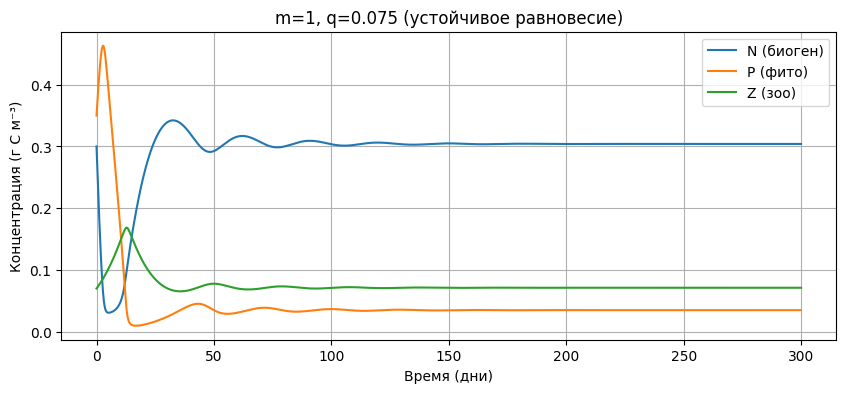

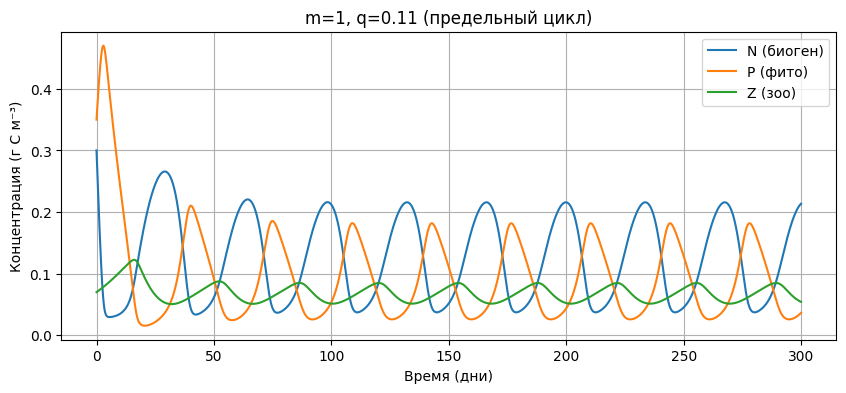

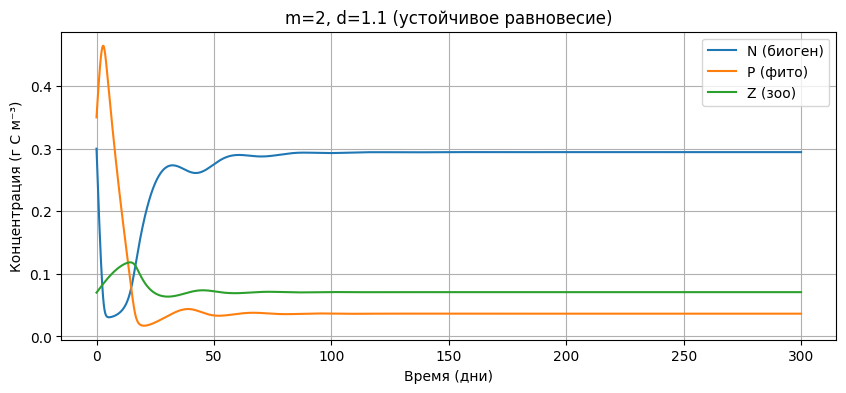

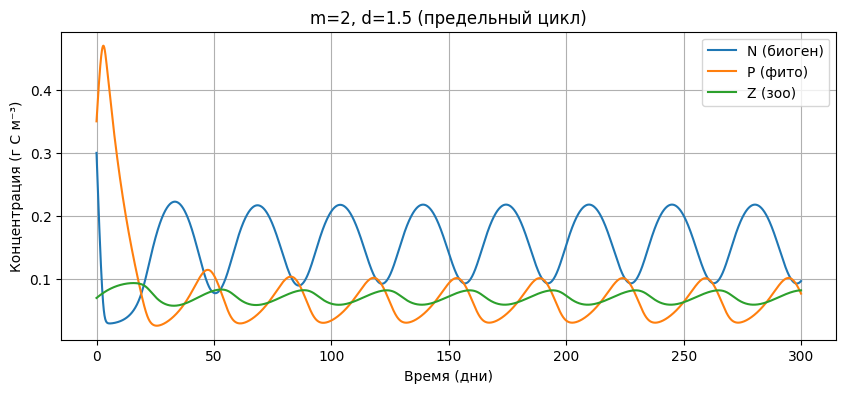

In [17]:
# Начальные условия
y0 = guess_init

# Для m=1
sol1 = plot_time_series(0.075, 1, y0, title='m=1, q=0.075 (устойчивое равновесие)')
sol2 = plot_time_series(0.11, 1, y0, title='m=1, q=0.11 (предельный цикл)')

# Для m=2
sol3 = plot_time_series(1.1, 2, y0, title='m=2, d=1.1 (устойчивое равновесие)')
sol4 = plot_time_series(1.5, 2, y0, title=f'm=2, d=1.5 (предельный цикл)')

# Подтверждаем положительность решений для решений, отображенных на временных рядах.

In [18]:
print(f'Положительность для m=1, q=0.075: {check_positivity(sol1)}')
print(f'Положительность для m=1, q=0.11: {check_positivity(sol2)}')
print(f'Положительность для m=2, d=1.1: {check_positivity(sol3)}')
print(f'Положительность для m=2, d=1.5: {check_positivity(sol4)}')

Положительность для m=1, q=0.075: True
Положительность для m=1, q=0.11: True
Положительность для m=2, d=1.1: True
Положительность для m=2, d=1.5: True
